In [2]:
# Always pull shared data from `financial_crime` module
%load_ext autoreload
%autoreload 2

In [3]:
random_state=42

In [4]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from collections import Counter
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

In [66]:
from financial_crime.config import PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR

## Improvements to Feature Engineering

In [6]:
X = pd.read_parquet(f'{PROCESSED_DATA_DIR}/features.parquet')
X

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,ID,event_timestamp,Amount_Received_USD,Amount_Paid_USD,Account_Same,Bank_Same,account_pair,pair_transaction_count,Account_Transacted_With_Account1_Before
0,2022/09/01 00:00,1522,800F116A0,1522,800F116A0,65272.09,Euro,65272.09,Euro,Reinvestment,72a64f9b-982b-4e83-b0b3-82d5bcc0f5ac,2022-09-01 00:00:00,6.491309e+04,6.491309e+04,1,1,800F116A0::800F116A0,1,0
1,2022/09/01 00:00,22,800D856D0,22,800D856D0,6007.61,Euro,6007.61,Euro,Reinvestment,4246e54d-f307-4d2e-b91c-b0f7309747d5,2022-09-01 00:00:00,5.974568e+03,5.974568e+03,1,1,800D856D0::800D856D0,1,0
2,2022/09/01 00:00,1729,8008C1090,23842,801A97310,13245.37,US Dollar,13245.37,US Dollar,Cheque,20f28fbe-35ff-450f-8b52-cdda9401f89c,2022-09-01 00:00:00,1.324537e+04,1.324537e+04,0,0,8008C1090::801A97310,1,0
3,2022/09/01 00:00,228101,80A464B90,228101,80A464B90,17642126.68,Australian Dollar,17642126.68,Australian Dollar,Reinvestment,45527a74-ced7-4238-8fec-aa15e5f30f6a,2022-09-01 00:00:00,1.197724e+07,1.197724e+07,1,1,80A464B90::80A464B90,1,0
4,2022/09/01 00:00,1665,800D73230,1665,800D73230,17.25,Euro,17.25,Euro,Reinvestment,f6ad5a58-6cf7-4788-9670-cc3cb72e5346,2022-09-01 00:00:00,1.715513e+01,1.715513e+01,1,1,800D73230::800D73230,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028340,2022/09/18 10:02,9371,8043A0FB0,16163,802F78670,3749.14,US Dollar,3749.14,US Dollar,ACH,1f29a88b-bb89-4080-8646-fa707d78deb2,2022-09-18 10:02:00,3.749140e+03,3.749140e+03,0,0,8043A0FB0::802F78670,1,0
5028341,2022/09/18 11:18,9371,8043A0FB0,13858,8095526B0,1785.27,Euro,1785.27,Euro,ACH,9fc8e741-a1db-40ae-a840-4de8284ce5f9,2022-09-18 11:18:00,1.775451e+03,1.775451e+03,0,0,8043A0FB0::8095526B0,1,0
5028342,2022/09/18 11:18,9371,8043A0FB0,9371,8043A0FB0,1785.27,Euro,2091.95,US Dollar,ACH,5ceee093-170b-4303-89ed-130380b74eca,2022-09-18 11:18:00,1.775451e+03,2.091950e+03,1,1,8043A0FB0::8043A0FB0,7,1
5028343,2022/09/18 12:58,9371,8043A0FB0,1124,8026687E0,2154.54,US Dollar,2154.54,US Dollar,ACH,a2a8026e-01a0-4600-ab80-cccd35baa351,2022-09-18 12:58:00,2.154540e+03,2.154540e+03,0,0,8043A0FB0::8026687E0,1,0


In [7]:
y = pd.read_parquet(f'{PROCESSED_DATA_DIR}/labels.parquet')['Is Laundering']
y

0          0
1          0
2          0
3          0
4          0
          ..
5028340    1
5028341    1
5028342    0
5028343    1
5028344    1
Name: Is Laundering, Length: 5028345, dtype: int64

In [9]:
categorical_features = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(X[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_cleaned = pd.concat([X.drop(categorical_features, axis=1), one_hot_df], axis=1)
X_cleaned

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,ID,event_timestamp,Amount_Received_USD,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:00,1522,800F116A0,1522,800F116A0,65272.09,65272.09,72a64f9b-982b-4e83-b0b3-82d5bcc0f5ac,2022-09-01 00:00:00,6.491309e+04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:00,22,800D856D0,22,800D856D0,6007.61,6007.61,4246e54d-f307-4d2e-b91c-b0f7309747d5,2022-09-01 00:00:00,5.974568e+03,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2022/09/01 00:00,1729,8008C1090,23842,801A97310,13245.37,13245.37,20f28fbe-35ff-450f-8b52-cdda9401f89c,2022-09-01 00:00:00,1.324537e+04,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2022/09/01 00:00,228101,80A464B90,228101,80A464B90,17642126.68,17642126.68,45527a74-ced7-4238-8fec-aa15e5f30f6a,2022-09-01 00:00:00,1.197724e+07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:00,1665,800D73230,1665,800D73230,17.25,17.25,f6ad5a58-6cf7-4788-9670-cc3cb72e5346,2022-09-01 00:00:00,1.715513e+01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028340,2022/09/18 10:02,9371,8043A0FB0,16163,802F78670,3749.14,3749.14,1f29a88b-bb89-4080-8646-fa707d78deb2,2022-09-18 10:02:00,3.749140e+03,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5028341,2022/09/18 11:18,9371,8043A0FB0,13858,8095526B0,1785.27,1785.27,9fc8e741-a1db-40ae-a840-4de8284ce5f9,2022-09-18 11:18:00,1.775451e+03,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5028342,2022/09/18 11:18,9371,8043A0FB0,9371,8043A0FB0,1785.27,2091.95,5ceee093-170b-4303-89ed-130380b74eca,2022-09-18 11:18:00,1.775451e+03,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5028343,2022/09/18 12:58,9371,8043A0FB0,1124,8026687E0,2154.54,2154.54,a2a8026e-01a0-4600-ab80-cccd35baa351,2022-09-18 12:58:00,2.154540e+03,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Has Account sent money to Account.1 before?
For each transaction, sweep all other transactions for that account occuring **before** it. Find the # of times account sent money to account.1 before

In [10]:
# Sort features and labels together so each transaction keeps its target.
sort_order = X_cleaned['event_timestamp'].sort_values().index
X_cleaned = X_cleaned.loc[sort_order].reset_index(drop=True)
y = y.loc[sort_order].reset_index(drop=True)

X_cleaned['past_occurrences'] = X_cleaned.groupby(['Account', 'Account.1']).cumcount()
X_cleaned['Account_Transacted_With_Account1_Before'] = (X_cleaned['past_occurrences'] > 0).astype(int)
X_cleaned = X_cleaned.drop(columns=['past_occurrences'])

### How often does this account make that type of payment?
If an account only uses credit card and suddenly does a bitcoin payment that could be pretty suspect

In [11]:
# The DF is already sorted by timestamp from the last engineered feature

payment_cols = [col for col in X_cleaned.columns if col.startswith('Payment Format_')]

windows = {
    '10s': 'Tx_Last_10_Sec',
    '30s': 'Tx_Last_30_Sec',
    '1min': 'Tx_Last_1_Min',
    '5min': 'Tx_Last_5_Min',
    '1h': 'Tx_Last_1_Hour',
    '1D': 'Tx_Last_1_Day',
    '10D': 'Tx_Last_10_Days'
}

grouped = X_cleaned.groupby('Account')

for window_size, window_label in windows.items():
    for pay_col in payment_cols:
        # Create a clean column name (e.g., 'Payment Format_Bitcoin_last_5_min')
        new_col_name = f"{pay_col}_Last_{window_label.replace('Tx_Last_', '')}"
        
        # Calculate the rolling sum of 1s and 0s
        X_cleaned[new_col_name] = (
            grouped.rolling(window_size, on='event_timestamp')
            [pay_col]
            .sum()  # Use .sum() because 1 + 1 + 0 = 2 transactions of this type
            .values
        )

In [12]:
# Calculate the "All Time" number of transactions by Payment Format
for pay_col in payment_cols:
    X_cleaned[f"{pay_col}_Tx_All_Time"] = (
        X_cleaned.groupby('Account')[pay_col]
        .cumsum()
    )


In [13]:
X_cleaned

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,ID,event_timestamp,Amount_Received_USD,...,Payment Format_Credit Card_Last_10_Days,Payment Format_Reinvestment_Last_10_Days,Payment Format_Wire_Last_10_Days,Payment Format_ACH_Tx_All_Time,Payment Format_Bitcoin_Tx_All_Time,Payment Format_Cash_Tx_All_Time,Payment Format_Cheque_Tx_All_Time,Payment Format_Credit Card_Tx_All_Time,Payment Format_Reinvestment_Tx_All_Time,Payment Format_Wire_Tx_All_Time
0,2022/09/01 00:00,1522,800F116A0,1522,800F116A0,65272.09,65272.09,72a64f9b-982b-4e83-b0b3-82d5bcc0f5ac,2022-09-01 00:00:00,64913.093505,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:00,16136,801442F30,23833,8018859B0,362.66,362.66,b8a5d6f1-1910-4b8d-abd5-4583f57c5c19,2022-09-01 00:00:00,362.660000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2022/09/01 00:00,26698,80BFCB8D0,26698,80BFCB8D0,11.93,11.93,3be3733a-a472-4987-839c-a109fbe13c7f,2022-09-01 00:00:00,11.930000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2022/09/01 00:00,240229,80EE6C700,240229,80EE6C700,17.56,17.56,67b59194-9355-4cbe-9a67-adfc13e172a2,2022-09-01 00:00:00,17.883104,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:00,115915,80BFC60E0,115915,80BFC60E0,19.81,19.81,22e2b127-5302-4341-8d58-396852b2aaf3,2022-09-01 00:00:00,19.810000,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028340,2022/09/18 10:02,9371,8043A0FB0,16163,802F78670,3749.14,3749.14,1f29a88b-bb89-4080-8646-fa707d78deb2,2022-09-18 10:02:00,3749.140000,...,0.0,0.0,0.0,16.0,0.0,7.0,9.0,8.0,2.0,1.0
5028341,2022/09/18 11:18,9371,8043A0FB0,13858,8095526B0,1785.27,1785.27,9fc8e741-a1db-40ae-a840-4de8284ce5f9,2022-09-18 11:18:00,1775.451015,...,0.0,0.0,0.0,17.0,0.0,7.0,9.0,8.0,2.0,1.0
5028342,2022/09/18 11:18,9371,8043A0FB0,9371,8043A0FB0,1785.27,2091.95,5ceee093-170b-4303-89ed-130380b74eca,2022-09-18 11:18:00,1775.451015,...,0.0,0.0,0.0,18.0,0.0,7.0,9.0,8.0,2.0,1.0
5028343,2022/09/18 12:58,9371,8043A0FB0,1124,8026687E0,2154.54,2154.54,a2a8026e-01a0-4600-ab80-cccd35baa351,2022-09-18 12:58:00,2154.540000,...,0.0,0.0,0.0,19.0,0.0,7.0,9.0,8.0,2.0,1.0


### Drop Cols

In [14]:
cols_to_drop = [
    "ID",
    "event_timestamp",
    "Timestamp",
    "To Bank",
    "From Bank",
    "Account",
    "Account.1",
    "account_pair",
    "pair_transaction_count",
]

In [15]:
X_cleaned.drop(cols_to_drop, axis=1, inplace=True)

In [16]:
X_cleaned

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Account_Same,Bank_Same,Account_Transacted_With_Account1_Before,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,...,Payment Format_Credit Card_Last_10_Days,Payment Format_Reinvestment_Last_10_Days,Payment Format_Wire_Last_10_Days,Payment Format_ACH_Tx_All_Time,Payment Format_Bitcoin_Tx_All_Time,Payment Format_Cash_Tx_All_Time,Payment Format_Cheque_Tx_All_Time,Payment Format_Credit Card_Tx_All_Time,Payment Format_Reinvestment_Tx_All_Time,Payment Format_Wire_Tx_All_Time
0,65272.09,65272.09,64913.093505,64913.093505,1,1,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,362.66,362.66,362.660000,362.660000,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,11.93,11.93,11.930000,11.930000,1,1,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,17.56,17.56,17.883104,17.883104,1,1,0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,19.81,19.81,19.810000,19.810000,1,1,0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028340,3749.14,3749.14,3749.140000,3749.140000,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,16.0,0.0,7.0,9.0,8.0,2.0,1.0
5028341,1785.27,1785.27,1775.451015,1775.451015,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,17.0,0.0,7.0,9.0,8.0,2.0,1.0
5028342,1785.27,2091.95,1775.451015,2091.950000,1,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,18.0,0.0,7.0,9.0,8.0,2.0,1.0
5028343,2154.54,2154.54,2154.540000,2154.540000,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,19.0,0.0,7.0,9.0,8.0,2.0,1.0


### Splitting Data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, 
                                                    y, 
                                                    test_size=0.2,
                                                    shuffle=False,
                                                    random_state=random_state,
)

### Scaling

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_train_scaled_df

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Account_Same,Bank_Same,Account_Transacted_With_Account1_Before,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,...,Payment Format_Credit Card_Last_10_Days,Payment Format_Reinvestment_Last_10_Days,Payment Format_Wire_Last_10_Days,Payment Format_ACH_Tx_All_Time,Payment Format_Bitcoin_Tx_All_Time,Payment Format_Cash_Tx_All_Time,Payment Format_Cheque_Tx_All_Time,Payment Format_Credit Card_Tx_All_Time,Payment Format_Reinvestment_Tx_All_Time,Payment Format_Wire_Tx_All_Time
0,-0.005790,-0.005134,-0.011436,-0.011481,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238696,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
1,-0.005851,-0.005205,-0.013853,-0.013922,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238543,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210100,-1.203071,-0.401590
2,-0.005851,-0.005206,-0.013866,-0.013935,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238543,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
3,-0.005851,-0.005206,-0.013866,-0.013935,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238391,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
4,-0.005851,-0.005206,-0.013866,-0.013935,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238238,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4022671,-0.005802,-0.005148,-0.013853,-0.013922,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238238,-1.199246,0.327067,-0.522295,-0.04509,-0.211179,-0.209558,-0.208572,-1.203071,-0.401590
4022672,-0.005796,-0.005142,-0.013851,-0.013920,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238238,-1.199246,0.327067,-0.522295,-0.04509,-0.211179,-0.207344,-0.203986,-1.203071,-0.401590
4022673,-0.005851,-0.005205,-0.013833,-0.013901,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238086,-1.199246,0.327067,-0.522295,-0.04509,-0.211179,-0.209420,-0.208572,1.440121,-0.401590
4022674,-0.005851,-0.005205,-0.013864,-0.013932,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238086,-1.199246,0.327067,2.508692,-0.04509,-0.209198,-0.206237,-0.206388,0.118525,2.581963


### Undersampling

In [20]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=random_state)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_scaled_df, y_train)

print("Resampled dataset shape:", Counter(y_train_resampled))

Original dataset shape: Counter({0: 5023312, 1: 5033})
Resampled dataset shape: Counter({0: 6668, 1: 3334})


In [21]:
X_train_resampled

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Account_Same,Bank_Same,Account_Transacted_With_Account1_Before,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,...,Payment Format_Credit Card_Last_10_Days,Payment Format_Reinvestment_Last_10_Days,Payment Format_Wire_Last_10_Days,Payment Format_ACH_Tx_All_Time,Payment Format_Bitcoin_Tx_All_Time,Payment Format_Cash_Tx_All_Time,Payment Format_Cheque_Tx_All_Time,Payment Format_Credit Card_Tx_All_Time,Payment Format_Reinvestment_Tx_All_Time,Payment Format_Wire_Tx_All_Time
777248,-0.005847,-0.005201,-0.013709,-0.013776,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.236714,-1.199246,-0.047493,-0.522295,-0.04509,-0.210849,-0.209974,-0.209882,0.118525,0.095669
2661046,-0.005851,-0.005205,-0.013862,-0.013931,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.237476,-1.199246,-0.422054,0.740616,-0.04509,-0.211179,-0.209282,-0.209663,0.118525,0.095669
2375758,-0.005816,-0.005164,-0.013843,-0.013912,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.235646,-1.199246,-0.422054,-0.522295,-0.04509,0.163063,0.170299,0.181631,-1.203071,-0.401590
2895347,-0.005851,-0.005206,-0.013866,-0.013935,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238238,-1.199246,-0.422054,1.498363,-0.04509,-0.211179,-0.208728,-0.207698,1.440121,-0.401590
1692853,-0.005848,-0.005201,-0.013720,-0.013788,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.237171,-1.199246,-0.422054,-0.522295,-0.04509,2.796948,2.660891,2.662813,-1.203071,-0.401590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019857,-0.005847,-0.005201,-0.013696,-0.013763,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238696,0.110350,-0.422054,-0.269712,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
4020013,-0.005805,-0.005152,-0.013601,-0.013667,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238696,-1.199246,-0.422054,0.235452,-0.04509,-0.208538,-0.209420,-0.210319,0.118525,-0.401590
4020477,-0.005837,-0.005189,-0.013293,-0.013357,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238543,-1.199246,-0.422054,-0.017130,-0.04509,-0.209858,-0.208451,-0.207698,1.440121,0.095669
4020868,-0.005839,-0.005192,-0.013397,-0.013461,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238543,1.419946,0.327067,-0.269712,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590


In [22]:
X_train_resampled = X_train_resampled.sort_index()

In [23]:
y_train_resampled = y_train_resampled.sort_index()

In [24]:
X_train_resampled

,Amount Received,Amount Paid,Amount_Received_USD,Amount_Paid_USD,Account_Same,Bank_Same,Account_Transacted_With_Account1_Before,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,...,Payment Format_Credit Card_Last_10_Days,Payment Format_Reinvestment_Last_10_Days,Payment Format_Wire_Last_10_Days,Payment Format_ACH_Tx_All_Time,Payment Format_Bitcoin_Tx_All_Time,Payment Format_Cash_Tx_All_Time,Payment Format_Cheque_Tx_All_Time,Payment Format_Credit Card_Tx_All_Time,Payment Format_Reinvestment_Tx_All_Time,Payment Format_Wire_Tx_All_Time
12,-0.005594,-0.004906,-0.003580,-0.003549,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.237933,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210389,-0.210319,-1.203071,-0.401590
221,-0.005844,-0.005197,-0.013571,-0.013637,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.228784,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
487,-0.005850,-0.005205,-0.013832,-0.013900,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.214907,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
1334,-0.004991,-0.004205,0.021157,0.021430,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.180444,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
1374,-0.005825,-0.005175,-0.012819,-0.012877,2.463702,2.284522,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.178461,-1.199246,-0.422054,-0.522295,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4020604,-0.005851,-0.005206,-0.013865,-0.013934,-0.405893,2.284522,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238238,0.110350,-0.422054,0.993199,-0.04509,-0.209198,-0.207483,-0.206825,-1.203071,5.565516
4020868,-0.005839,-0.005192,-0.013397,-0.013461,-0.405893,-0.437728,-1.768563,-0.167414,-0.173676,-0.119434,...,-0.238543,1.419946,0.327067,-0.269712,-0.04509,-0.211179,-0.210527,-0.210319,0.118525,-0.401590
4021007,-0.005851,-0.005205,-0.013862,-0.013930,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.237933,-1.199246,-0.422054,-0.269712,-0.04509,-0.206888,-0.208590,-0.208572,0.118525,-0.401590
4021071,-0.005813,-0.005161,-0.013460,-0.013525,-0.405893,-0.437728,0.565431,-0.167414,-0.173676,-0.119434,...,-0.238696,1.419946,-0.422054,3.013856,-0.04509,-0.208538,-0.206929,-0.205951,1.440121,0.095669


In [25]:
y_train_resampled

12         0
221        0
487        0
1334       0
1374       0
          ..
4020604    0
4020868    1
4021007    0
4021071    1
4022550    0
Name: Is Laundering, Length: 10002, dtype: int64

### Hyperparamer tuning

In [44]:
import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import TimeSeriesSplit
import optuna


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    decision_threshold = trial.suggest_float('decision_threshold', 0.1, 0.9)

    tscv = TimeSeriesSplit(n_splits=3)

    fold_f1_scores = []
    pr_auc_scores = []
    # 3. Time-aware cross-validation loop
    for train_index, test_index in tscv.split(X_train_resampled):
        X_tr, X_te = X_train_resampled.iloc[train_index], X_train_resampled.iloc[test_index]
        y_tr, y_te = y_train_resampled.iloc[train_index], y_train_resampled.iloc[test_index]
        
        # Fit model
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state
        )
        model.fit(X_tr, y_tr)

        # Predict target probability
        fraud_probabilities = model.predict_proba(X_te)[:, 1]
        # Apply the optimized decision threshold for this trial
        y_prob = (fraud_probabilities >= decision_threshold).astype(int)
        
        # Calculate F1 Score
        # score = f1_score(y_te, y_prob)
        # fold_f1_scores.append(score)

        # Calculate PR-AUC
        # 1. Compute precision and recall for different thresholds
        precision, recall, thresholds = precision_recall_curve(y_te, y_prob)
        # 2. Calculate the area under the curve using the trapezoidal rule
        pr_auc = auc(recall, precision)
        pr_auc_scores.append(pr_auc)
        
    # Return average F1 score to maximize
    # return np.mean(fold_f1_scores)

    # Return average PR-AUC to maximize
    return np.mean(pr_auc_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_f1_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_f1_df)

[I 2026-08-25 08:06:50,638] A new study created in memory with name: no-name-25dad770-fc9f-4d93-947a-961cd34ff05b
[I 2026-08-25 08:07:03,298] Trial 0 finished with value: 0.9058940465023042 and parameters: {'n_estimators': 283, 'max_depth': 4, 'decision_threshold': 0.5465730062113362}. Best is trial 0 with value: 0.9058940465023042.
[I 2026-08-25 08:07:04,687] Trial 1 finished with value: 0.600106565369337 and parameters: {'n_estimators': 59, 'max_depth': 2, 'decision_threshold': 0.889419890988369}. Best is trial 0 with value: 0.9058940465023042.
[I 2026-08-25 08:07:23,761] Trial 2 finished with value: 0.8992200079524811 and parameters: {'n_estimators': 246, 'max_depth': 7, 'decision_threshold': 0.2508565850988106}. Best is trial 0 with value: 0.9058940465023042.
[I 2026-08-25 08:07:24,613] Trial 3 finished with value: 0.5459835051546391 and parameters: {'n_estimators': 36, 'max_depth': 2, 'decision_threshold': 0.8897932145712385}. Best is trial 0 with value: 0.9058940465023042.
[I 202

,number,value,datetime_start,datetime_complete,duration,params_decision_threshold,params_max_depth,params_n_estimators,state
72,72,0.913475,2026-08-25 08:14:31.421156,2026-08-25 08:14:34.331107,0 days 00:00:02.909951,0.536425,4,65,COMPLETE
71,71,0.913282,2026-08-25 08:14:28.550635,2026-08-25 08:14:31.421156,0 days 00:00:02.870521,0.547681,4,65,COMPLETE
46,46,0.913125,2026-08-25 08:13:13.026190,2026-08-25 08:13:15.113525,0 days 00:00:02.087335,0.580317,3,61,COMPLETE
91,91,0.913026,2026-08-25 08:15:44.979538,2026-08-25 08:15:48.610881,0 days 00:00:03.631343,0.532252,3,108,COMPLETE
99,99,0.912887,2026-08-25 08:16:12.874703,2026-08-25 08:16:15.570403,0 days 00:00:02.695700,0.559554,3,80,COMPLETE


### Model Eval

In [60]:
model = GradientBoostingClassifier(
    n_estimators=65,
    max_depth=4,
    random_state=random_state
)

In [61]:
decision_threshold = 0.536

In [62]:
model.fit(X_train_resampled, y_train_resampled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= decision_threshold).astype(int)

print(classification_report(y_true=y_test, y_pred=y_pred))

c:\Users\caleb\Projects\financial-crime\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1003970
           1       0.03      0.90      0.05      1699

    accuracy                           0.94   1005669
   macro avg       0.51      0.92      0.51   1005669
weighted avg       1.00      0.94      0.97   1005669



In [68]:
from sklearn.metrics import precision_recall_curve

# Get precision, recall, and threshold arrays
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

c:\Users\caleb\Projects\financial-crime\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


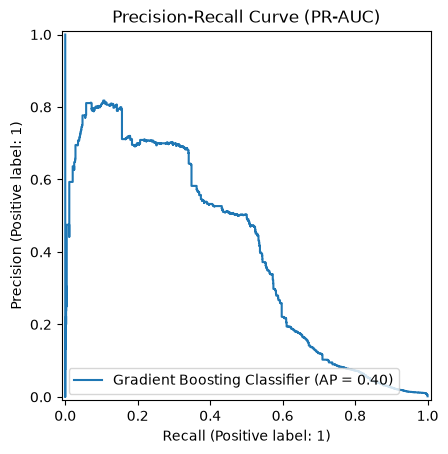

In [67]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

disp = PrecisionRecallDisplay.from_estimator(
    model, X_test_scaled, y_test, name="Gradient Boosting Classifier"
)
plt.title("Precision-Recall Curve (PR-AUC)")

save_loc = FIGURES_DIR / 'pr-auc_ibm.png'
plt.savefig(save_loc)
None

In [85]:
# Define your target threshold
target_threshold = 0.536

# Find the index of the closest value in the thresholds array
idx = np.argmin(np.abs(thresholds - target_threshold))

# Retrieve the corresponding precision and recall values
target_precision = precision[idx]
target_recall = recall[idx]

print(f"At threshold {target_threshold:.2f}: Precision = {target_precision:.2f}, Recall = {target_recall:.2f}")


At threshold 0.54: Precision = 0.03, Recall = 0.90


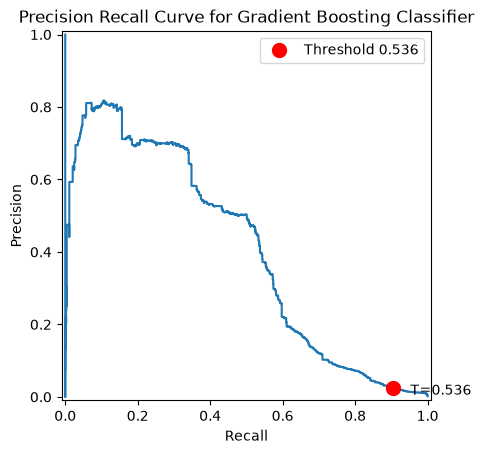

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Plot the standard curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

# Overlay the specific threshold point
plt.plot(target_recall, target_precision, 'ro', markersize=10, label=f'Threshold {target_threshold}')
plt.annotate(f' T={target_threshold}', (target_recall, target_precision), textcoords="offset points", xytext=(10,-5), ha='left')
plt.title("Precision Recall Curve for Gradient Boosting Classifier")

plt.legend()

save_loc = FIGURES_DIR / 'pr-auc_threshold_536_ibm.png'
plt.savefig(save_loc)
None

In [82]:
# Define your target threshold
target_threshold = 0.98

# Find the index of the closest value in the thresholds array
idx = np.argmin(np.abs(thresholds - target_threshold))

# Retrieve the corresponding precision and recall values
target_precision = precision[idx]
target_recall = recall[idx]

print(f"At threshold {target_threshold:.2f}: Precision = {target_precision:.2f}, Recall = {target_recall:.2f}")

At threshold 0.98: Precision = 0.81, Recall = 0.13


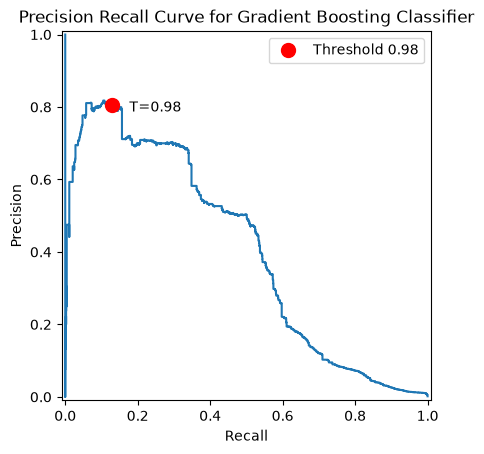

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Plot the standard curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

# Overlay the specific threshold point
plt.plot(target_recall, target_precision, 'ro', markersize=10, label=f'Threshold {target_threshold}')
plt.annotate(f' T={target_threshold}', (target_recall, target_precision), textcoords="offset points", xytext=(10,-5), ha='left')
plt.title("Precision Recall Curve for Gradient Boosting Classifier")

plt.legend()

save_loc = FIGURES_DIR / 'pr-auc_threshold_98_ibm.png'
plt.savefig(save_loc)
None